In [1]:
import sys
sys.path.append('../')
from tqdm import tqdm
import os
import torch
import pandas as pd
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from utilities import load_embedding, print_exams
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from torch.utils.data import Dataset, DataLoader
from sklearn.decomposition import PCA
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import pandas as pd
import numpy as np

# 設置設備
device = torch.device('cuda:0')

class fluProfiler_Dataset(Dataset):
    def __init__(self, DataFrame):
        # 生成嵌入文件名
        self.emb_file_name_a = ('matrix_' + DataFrame['seq_id_a']).tolist()
        self.emb_file_name_b = ('matrix_' + DataFrame['seq_id_b']).tolist()
        self.emb_file_name_c = ('matrix_' + DataFrame['seq_id_c']).tolist()
        self.emb_file_name_d = ('matrix_' + DataFrame['seq_id_d']).tolist()

        # 轉換傳代類別為張量
        self.strainPassCats = convert_Pass2tensor(
            ('<cls>' + DataFrame['serumPassCat'] + '<eos>' + 
             DataFrame['virusPassCat'] + '<eos>').tolist()
        )
        
        # 標籤
        self.labels = torch.tensor(DataFrame['label'].tolist())
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return (self.emb_file_name_a[idx], self.emb_file_name_b[idx], 
                self.emb_file_name_c[idx], self.emb_file_name_d[idx], 
                self.strainPassCats[idx], self.labels[idx])

def convert_Pass2tensor(pass_cats):
    result = [
        item.replace('<cls>', '0').replace('<eos>', '1')
             .replace('<EGG>', '2').replace('<CELL>', '3').replace('<BOTH>', '4')
        for item in pass_cats
    ]
    result = torch.tensor([[int(number) for number in [char for char in item]] for item in result])
    return result

def generate_matrix(matrix_list):
    seq_len = [mat.shape[0] for mat in matrix_list]
    max_len = max(seq_len)
    mask_list = []
    
    for i in range(len(matrix_list)): 
        # 填充矩陣到最大長度
        matrix_list[i] = F.pad(matrix_list[i], (0, 0, 0, max_len - seq_len[i]))
        mask = torch.concat((torch.ones(1,seq_len[i]),torch.zeros(1,max_len-seq_len[i])),axis=1)
        mask_list.append(mask)
    
    matrix = torch.stack(matrix_list)
    mask = torch.stack(mask_list).view(len(matrix_list), max_len)
    return matrix, mask

def list2df(mylist, period):
    merged_rows = []
    for i in range(0, len(mylist), period):
        merged_row = []
        for j in range(period):
            merged_row += mylist[i + j]
        merged_rows.append(merged_row)
    return pd.DataFrame(merged_rows)

## 数据加载

In [ ]:
Crick_early = pd.read_csv('../../data/data_40/all.csv')
Crick_41 = pd.read_csv('../../data/data_40/Crick_41_mapped.csv')
Crick_42 = pd.read_csv('../../data/data_40/Crick_42.csv')
Crick_43 = pd.read_csv('../../data/data_40/Crick_43.csv')
CDC_data = pd.read_csv('../../data/data_40/CDC_all.csv')
CNIC_data = pd.read_csv('../../data/data_40/CNIC_all.csv')
Crick_ultra = pd.read_csv('../../data/data_40/fluProfiler_ultra/All_data.csv')

## 加载表格和embedding

In [ ]:
df_41 = pd.read_csv('../../data/data_40/Crick_41.csv').drop_duplicates(subset=['seq_c']).reset_index(drop=True)
df_42 = pd.read_csv('../../data/data_40/Crick_42.csv').drop_duplicates(subset=['seq_c']).reset_index(drop=True)

In [ ]:
# load embedding
Crick_df = pd.read_csv('../../data/data_40/all.csv', index_col=False)
Crick_df = Crick_df[(Crick_df['seq_a'].str.len() >= 566) & (Crick_df['seq_c'].str.len() >= 566)]
sequence_names = pd.concat([Crick_df['seq_id_a'], Crick_df['seq_id_c']]).unique().tolist()
sequence_names = ['matrix_' + item + '.pt' for item in sequence_names]
emb_dict_Crick = load_embedding("../../data/data_40/embedding_Crick", files=sequence_names)

Loading tensor: 100%|██████████| 5216/5216 [13:08<00:00,  6.61file/s]


In [ ]:
emb_dict_CDC = load_embedding("../../data/data_40/embedding_CDC")

Loading tensor: 100%|██████████| 4135/4135 [08:20<00:00,  8.26file/s]


In [6]:
emb_dict_CNIC = load_embedding("../../data/data_40/embedding_CNIC")

Loading tensor: 100%|██████████| 1958/1958 [02:31<00:00, 12.92file/s]


In [7]:
emb_dict_41 = load_embedding("../../data/data_40/embedding_41")

Loading tensor: 100%|██████████| 469/469 [00:17<00:00, 26.33file/s]


In [8]:
emb_dict_42 = load_embedding("../../data/data_40/embedding_42")

Loading tensor: 100%|██████████| 1142/1142 [00:43<00:00, 26.20file/s]


In [9]:
emb_dict_43 = load_embedding("../../data/data_40/embedding_43")

Loading tensor: 100%|██████████| 750/750 [00:28<00:00, 26.57file/s]


## 不同中心样本数据的一致性

In [10]:
# 按關鍵列分組，對標籤取平均值，其他列取第一個值
group_columns = ['seq_a', 'seq_b', 'seq_c', 'seq_d', 'serumPassCat', 'virusPassCat', 'institute']
agg_dict = {c: 'first' for c in Crick_ultra.columns if c not in group_columns}
agg_dict['label'] = 'mean'
data_all = Crick_ultra.groupby(group_columns, as_index=False).agg(agg_dict)

print(f"數據加載完成，總共 {len(data_all)} 條記錄")
print(f"包含的研究中心: {data_all['institute'].unique()}")

數據加載完成，總共 120295 條記錄
包含的研究中心: ['<Crick>' '<CDC>' '<CNIC>']


In [11]:
# 1.1.2 提取多中心重疊樣本
# group_columns = ['serumName', 'virusName', 'serumPassCat', 'virusPassCat']
group_columns = ['seq_a', 'seq_b', 'seq_c', 'seq_d', 'serumPassCat', 'virusPassCat']
result = data_all.groupby(group_columns).filter(lambda x: x['institute'].nunique() > 1)

print(f"找到 {len(result)} 個多中心重疊樣本")
print(f"涉及的研究中心: {result['institute'].unique()}")

# 查看不同中心的標籤分佈
label_changes = result.groupby(group_columns + ['institute'])['label'].unique()
print(f"標籤變化情況: {len(label_changes)} 個組合")

找到 1404 個多中心重疊樣本
涉及的研究中心: ['<CDC>' '<Crick>' '<CNIC>']
標籤變化情況: 1404 個組合


In [12]:
# 1.1.3 整理多中心數據用於比較
result = result.sort_values(by=group_columns + ['institute'], inplace=False)[group_columns + ['institute', 'Type', 'label']]
print("數據已按研究中心和類型排序")

數據已按研究中心和類型排序


In [13]:
# 1.1.4 創建研究中心間的配對比較數據
# 獲取所有唯一組合
identity = result[group_columns].drop_duplicates().reset_index(drop=True)

# 為每個研究中心創建數據
Crick_titer = identity.merge(result[result['institute'] == '<Crick>'], on=group_columns, how='right')
CNIC_titer = identity.merge(result[result['institute'] == '<CNIC>'], on=group_columns, how='right')
CDC_titer = identity.merge(result[result['institute'] == '<CDC>'], on=group_columns, how='right')

# 創建配對比較數據集
Crick_CNIC = Crick_titer.merge(CNIC_titer, on=group_columns, how='inner')
Crick_CDC = Crick_titer.merge(CDC_titer, on=group_columns, how='inner')
CNIC_CDC = CNIC_titer.merge(CDC_titer, on=group_columns, how='inner')

print(f"Crick-CNIC 配對: {len(Crick_CNIC)} 個樣本")
print(f"Crick-CDC 配對: {len(Crick_CDC)} 個樣本")
print(f"CNIC-CDC 配對: {len(CNIC_CDC)} 個樣本")

Crick-CNIC 配對: 147 個樣本
Crick-CDC 配對: 450 個樣本
CNIC-CDC 配對: 135 個樣本


In [15]:
# 1.1.5 定義相關性分析函數
def analyze_correlation(data, center1, center2, virus_type=None):
    """
    分析兩個研究中心之間的相關性
    
    參數:
    data: 配對數據
    center1, center2: 研究中心名稱
    virus_type: 病毒類型 ('H1N1' 或 'H3N2')，None表示全部
    """
    if virus_type:
        subset = data[data['Type_x'] == virus_type]
        print(f"\n{center1} vs {center2} - {virus_type} 分析:")
    else:
        subset = data
        print(f"\n{center1} vs {center2} - 全部數據分析:")
    
    print(f"樣本數量: {len(subset)}")
    
    if len(subset) > 0:
        result = print_exams(subset['label_x'], subset['label_y'])
        return result
    else:
        print("沒有足夠的樣本進行分析")
        return None

# 1.1.6 Crick vs CNIC 相關性分析
print("=" * 50)
print("CRICK vs CNIC 相關性分析")
print("=" * 50)

all_crick_cnic = analyze_correlation(Crick_CNIC, "Crick", "CNIC")
h1n1_crick_cnic = analyze_correlation(Crick_CNIC, "Crick", "CNIC", "H1N1")
h3n2_crick_cnic = analyze_correlation(Crick_CNIC, "Crick", "CNIC", "H3N2")

CRICK vs CNIC 相關性分析

Crick vs CNIC - 全部數據分析:
樣本數量: 147
MAE: 1.07441
MSE: 1.93987
pearson correlation: 0.74609
spearman correlation: 0.73469
R2_score: 0.52244

Crick vs CNIC - H1N1 分析:
樣本數量: 47
MAE: 1.09896
MSE: 1.69587
pearson correlation: 0.74826
spearman correlation: 0.42405
R2_score: 0.54528

Crick vs CNIC - H3N2 分析:
樣本數量: 100
MAE: 1.06288
MSE: 2.05455
pearson correlation: 0.55876
spearman correlation: 0.50413
R2_score: 0.07492


In [16]:
# 1.1.7 Crick vs CDC 相關性分析
print("=" * 50)
print("CRICK vs CDC 相關性分析")
print("=" * 50)

all_crick_cdc = analyze_correlation(Crick_CDC, "Crick", "CDC")
h1n1_crick_cdc = analyze_correlation(Crick_CDC, "Crick", "CDC", "H1N1")
h3n2_crick_cdc = analyze_correlation(Crick_CDC, "Crick", "CDC", "H3N2")

CRICK vs CDC 相關性分析

Crick vs CDC - 全部數據分析:
樣本數量: 450
MAE: 0.95110
MSE: 1.63225
pearson correlation: 0.76291
spearman correlation: 0.70039
R2_score: 0.39421

Crick vs CDC - H1N1 分析:
樣本數量: 194
MAE: 0.75238
MSE: 1.05906
pearson correlation: 0.69752
spearman correlation: 0.33084
R2_score: 0.41110

Crick vs CDC - H3N2 分析:
樣本數量: 256
MAE: 1.10170
MSE: 2.06663
pearson correlation: 0.73129
spearman correlation: 0.75029
R2_score: 0.24236


In [17]:
# 1.1.8 CNIC vs CDC 相關性分析
print("=" * 50)
print("CNIC vs CDC 相關性分析")
print("=" * 50)

all_cnic_cdc = analyze_correlation(CNIC_CDC, "CNIC", "CDC")
h1n1_cnic_cdc = analyze_correlation(CNIC_CDC, "CNIC", "CDC", "H1N1")
h3n2_cnic_cdc = analyze_correlation(CNIC_CDC, "CNIC", "CDC", "H3N2")

CNIC vs CDC 相關性分析

CNIC vs CDC - 全部數據分析:
樣本數量: 135
MAE: 1.15821
MSE: 2.32387
pearson correlation: 0.77106
spearman correlation: 0.67641
R2_score: 0.49215

CNIC vs CDC - H1N1 分析:
樣本數量: 72
MAE: 0.80851
MSE: 1.11315
pearson correlation: 0.92324
spearman correlation: 0.75310
R2_score: 0.84118

CNIC vs CDC - H3N2 分析:
樣本數量: 63
MAE: 1.55787
MSE: 3.70755
pearson correlation: 0.15657
spearman correlation: 0.16919
R2_score: -1.06749


## 病毒进化可视化

In [10]:
Crick_df = Crick_early.copy()
Crick_df = Crick_df[Crick_df['seq_c'].str.len() == 566].drop_duplicates(subset=['seq_c']).reset_index(drop=True)
vector_Crick = np.stack([np.asarray(emb_dict_Crick['matrix_'+str(HA_name)].max(axis=0)[0].to('cpu')) for HA_name in Crick_df['seq_id_c']])

In [ ]:
def cluster_virus(df, vector, drop_duplicate=False):

    if drop_duplicate:
        df_arr = pd.DataFrame(vector, columns=[f'col_{i}' for i in range(vector.shape[1])])
        df_merged = pd.concat([df.reset_index(drop=True), df_arr], axis=1)
        df_merged["virusDate"] = pd.to_datetime(df_merged["virusDate"], errors="coerce")
        
        aggregate_dict = {col: 'first' for col in df_merged.columns if col != 'seq_c'}
        aggregate_dict['virusDate'] = 'min'
        df_agg = df_merged.groupby('seq_c').agg(aggregate_dict).reset_index()
        df = df_agg.iloc[:, :-2560]
        vector = np.array(df_agg.iloc[:, -2560:])

    # elbow_method(vector)
    
    pca_2d = PCA(n_components=2, random_state=42)
    X_2d = pca_2d.fit_transform(vector)

    k = 2
    labels = KMeans(n_clusters=k, random_state=441).fit_predict(X_2d)
    
    df_plot = pd.DataFrame(X_2d, columns=['x', 'y'])
    df_plot['cluster'] = labels.astype(str)
    df_plot['type'] = df['Type'].tolist()
    df_plot['virusDate'] = df['virusDate']
    df_plot['virusIslID'] = df['virusIslID'].tolist()

    return df_plot

def plot_virus_scatter(df_plot, color_map=None, save_path=None):
    plt.figure(figsize=(5, 3.5))

    order = ['Crick', 'CDC', 'CNIC']  # 你想要的顺序

    for t in order:
        subdf = df_plot[df_plot['type'] == t]  # 筛选对应类型的数据
        if len(subdf) == 0:
            continue  # 防止某类不存在时报错

        plt.scatter(subdf["x"], subdf["y"],
                    label=t,
                    c=color_map.get(t, "gray"),
                    s=8, alpha=0.45, lw=0)

    # ===== 样式 =====
    plt.xlabel("component-1", fontsize=14)
    plt.ylabel("component-2", fontsize=14)
    
    plt.legend(frameon=False, fontsize=10, loc='upper left', bbox_to_anchor=(0.98, 1), 
    markerscale=2, alignment='left')

    plt.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    
    if save_path is not None:
        ext = os.path.splitext(save_path)[1].lower()

        if ext == '.png':
            plt.savefig(save_path, dpi=600, transparent=True,
                        pil_kwargs={"compress_level": 0}, bbox_inches="tight")
        elif ext == '.svg':
            plt.savefig(save_path, format='svg', bbox_inches="tight")
    else:
        plt.show()

def plot_virus_scatter_time(df_plot, save_path=None):
    """
    根据virusDate由浅到深绘制散点（自然色渐变：蓝→绿→黄）。
    """
    fig, ax = plt.subplots(figsize=(5, 3.5))

    # 确保时间格式并去掉NaT
    df_plot = df_plot.copy()
    df_plot["virusDate"] = pd.to_datetime(df_plot["virusDate"], errors="coerce")
    df_plot = df_plot.dropna(subset=["virusDate"])
    if df_plot.empty:
        raise ValueError("virusDate 列全部为空或无法解析为日期")

    # 按时间排序（保证后期点覆盖早期点）
    df_plot = df_plot.sort_values("virusDate")

    # 时间归一化（排除极端值，避免色带压缩）
    vmin = df_plot["virusDate"].quantile(0.05).timestamp()
    vmax = df_plot["virusDate"].quantile(0.95).timestamp()
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    # 自然色 colormap
    cmap = cm.get_cmap("cividis")

    # 绘制散点
    sc = ax.scatter(df_plot["x"], df_plot["y"],
                    c=df_plot["virusDate"].apply(lambda x: x.timestamp()),
                    cmap=cmap, norm=norm,
                    s=12, alpha=0.6, lw=0)

    # 颜色条
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.02, pad=0.02)
    ticks = np.linspace(vmin, vmax, 6)
    cbar.set_ticks(ticks)
    cbar.set_ticklabels(pd.to_datetime(ticks, unit="s").strftime("%Y"))  # 只显示年份
    cbar.set_label("virusDate", fontsize=10)

    # 样式
    ax.set_xlabel("component-1", fontsize=14)
    ax.set_ylabel("component-2", fontsize=14)
    ax.grid(True, linestyle="--", alpha=0.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # ax.set_aspect('equal')

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=600, transparent=True,
                    bbox_inches="tight", pil_kwargs={"compress_level": 0})
    else:
        plt.show()


### 流感季

#### 病毒

In [13]:
df_41 = Crick_41.copy()
df_41 = df_41.loc[(df_41['seq_c'].str.len() == 566),:]
df_41['Type'] = df_41['Type'] + '_2024NH'
df_42 = Crick_42.copy()
df_42 = df_42.loc[(df_42['seq_c'].str.len() == 566),:]
df_42['Type'] = df_42['Type'] + '_2024SH'
df_43 = Crick_43.copy()
df_43 = df_43.loc[(df_43['seq_c'].str.len() == 566),:]
df_43['Type'] = df_43['Type'] + '_2025NH'

all_df = pd.concat([Crick_df, df_41, df_42, df_43]).reset_index(drop=True)

In [14]:
vector_41 = np.stack([np.asarray(emb_dict_41['matrix_'+str(HA_name)].max(axis=0)[0].to('cpu')) for HA_name in df_41['seq_id_c']])
vector_42 = np.stack([np.asarray(emb_dict_42['matrix_'+str(HA_name)].max(axis=0)[0].to('cpu')) for HA_name in df_42['seq_id_c']])
vector_43 = np.stack([np.asarray(emb_dict_43['matrix_'+str(HA_name)].max(axis=0)[0].to('cpu')) for HA_name in df_43['seq_id_c']])
all_vector = np.vstack([vector_Crick, vector_41, vector_42, vector_43])

In [15]:
# all_df.to_csv('Evolution_data.csv', index=False)
# np.save("Evolution_vectors.npy", all_vector)
all_df = pd.read_csv('Evolution_data.csv')
all_vector = np.load('Evolution_vectors.npy')

FileNotFoundError: [Errno 2] No such file or directory: 'Evolution_data.csv'

In [16]:
color_map = {
        'H1N1': 'red',
        'H3N2': 'red',
        'H1N1_2024NH': 'cyan',
        'H3N2_2024NH': 'cyan',
        'H1N1_2024SH': 'magenta',
        'H3N2_2024SH': 'magenta',
        'H1N1_2025NH': 'orange',
        'H3N2_2025NH': 'orange'
    }

plot_df = cluster_virus(all_df, all_vector, drop_duplicate=True)

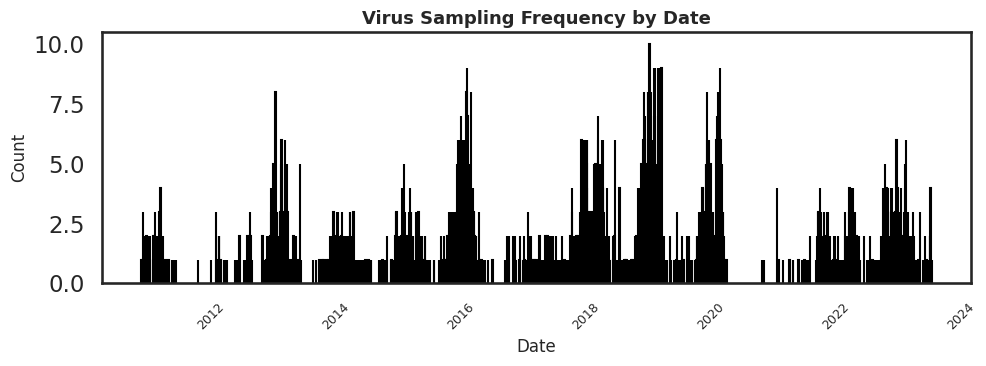

In [185]:
import pandas as pd
import matplotlib.pyplot as plt

# 假设你的时间列表叫 time_list
time_series = plot_df_filt.loc[plot_df_filt['type'] == 'H1N1', 'virusDate']
time_series = pd.to_datetime(time_series)

# 按日期统计频率
freq = time_series.value_counts().sort_index()

# 绘制按天的频率直方图
plt.figure(figsize=(10, 4))
plt.bar(freq.index, freq.values, width=1.0, color="#71B7ED", edgecolor="black")

plt.xlabel("Date", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("Virus Sampling Frequency by Date", fontsize=13, fontweight="bold")

plt.xticks(rotation=45, fontsize=9)
plt.tight_layout()
plt.show()

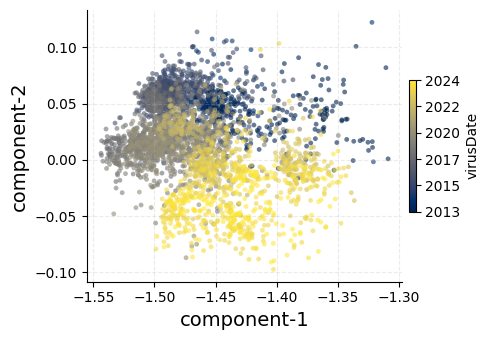

In [17]:
plot_df_filt = plot_df[plot_df['type'].isin(['H1N1', 'H1N1_2024NH', 'H1N1_2024SH', 'H1N1_2025NH'])]
plot_df_filt = plot_df_filt[plot_df_filt['virusDate'] >= '2010-08-31']
plot_df_filt = plot_df_filt[plot_df_filt['x'] < -1.3]
plot_df_filt = plot_df_filt[(plot_df_filt['y'] < 0.13) & (plot_df_filt['y'] > -0.1)]
plot_virus_scatter_time(plot_df_filt, save_path='H1N1_evo.png')

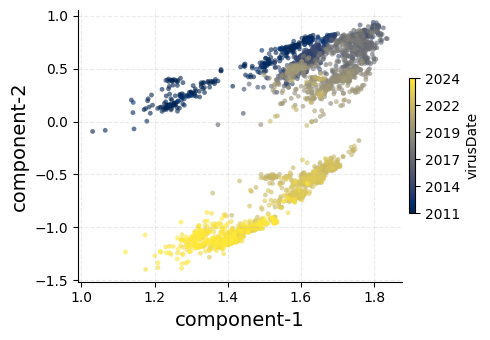

In [18]:
plot_df_filt = plot_df[plot_df['type'].isin(['H3N2', 'H3N2_2024NH', 'H3N2_2024SH', 'H3N2_2025NH'])]
# plot_df_filt = plot_df_filt[plot_df_filt['x'] > 1.1]
plot_df_filt = plot_df_filt[plot_df_filt['y'] < 1]
plot_virus_scatter_time(plot_df_filt, save_path='H3N2_evo.png')

#### 血清

In [61]:
Crick_df = Crick_early.copy()
Crick_df = Crick_df[Crick_df['seq_a'].str.len() == 566].drop_duplicates(subset=['seq_a']).reset_index(drop=True)

In [62]:
df_41 = Crick_41.copy()
df_41 = df_41.loc[(df_41['seq_a'].str.len() == 566),:].drop_duplicates(subset=['seq_a']).reset_index(drop=True)
df_41['Type'] = df_41['Type'] + '_2024NH'
df_42 = Crick_42.copy()
df_42 = df_42.loc[(df_42['seq_a'].str.len() == 566),:].drop_duplicates(subset=['seq_a']).reset_index(drop=True)
df_42['Type'] = df_42['Type'] + '_2024SH'
df_43 = Crick_43.copy()
df_43 = df_43.loc[(df_43['seq_a'].str.len() == 566),:].drop_duplicates(subset=['seq_a']).reset_index(drop=True)
df_43['Type'] = df_43['Type'] + '_2025NH'

all_df = pd.concat([Crick_df, df_41, df_42, df_43]).reset_index(drop=True)

In [ ]:
# load embedding
sequence_names = Crick_early['seq_id_a'].unique().tolist()
sequence_names = ['matrix_' + item + '.pt' for item in sequence_names]
Crick_early_serum_emb = load_embedding("../../data/data_40/embedding_Crick", files=sequence_names)

Loading tensor: 100%|██████████| 197/197 [00:26<00:00,  7.32file/s]


In [ ]:
sequence_names = df_41['seq_id_a'].unique().tolist()
sequence_names = ['matrix_' + item + '.pt' for item in sequence_names]
Crick_41_serum_emb = load_embedding("../../data/data_40/embedding_41", files=sequence_names)

Loading tensor: 100%|██████████| 14/14 [00:02<00:00,  5.81file/s]


In [ ]:
sequence_names = df_42['seq_id_a'].unique().tolist()
sequence_names = ['matrix_' + item + '.pt' for item in sequence_names]
Crick_42_serum_emb = load_embedding("../../data/data_40/embedding_42", files=sequence_names)

Loading tensor: 100%|██████████| 22/22 [00:01<00:00, 13.82file/s]


In [ ]:
sequence_names = df_43['seq_id_a'].unique().tolist()
sequence_names = ['matrix_' + item + '.pt' for item in sequence_names]
Crick_43_serum_emb = load_embedding("../../data/data_40/embedding_43", files=sequence_names)

Loading tensor: 100%|██████████| 16/16 [00:02<00:00,  6.04file/s]


In [66]:
vector_Crick_early = np.stack([np.asarray(Crick_early_serum_emb['matrix_'+str(HA_name)].max(axis=0)[0].to('cpu')) for HA_name in Crick_df['seq_id_a']])
vector_41 = np.stack([np.asarray(Crick_41_serum_emb['matrix_'+str(HA_name)].max(axis=0)[0].to('cpu')) for HA_name in df_41['seq_id_a']])
vector_42 = np.stack([np.asarray(Crick_42_serum_emb['matrix_'+str(HA_name)].max(axis=0)[0].to('cpu')) for HA_name in df_42['seq_id_a']])
vector_43 = np.stack([np.asarray(Crick_43_serum_emb['matrix_'+str(HA_name)].max(axis=0)[0].to('cpu')) for HA_name in df_43['seq_id_a']])
all_vector = np.vstack([vector_Crick_early, vector_41, vector_42, vector_43])

In [67]:
all_vector.shape 

(232, 2560)

In [68]:
color_map = {
        'H1N1': 'red',
        'H3N2': 'blue',
        'H1N1_2024NH': 'cyan',
        'H3N2_2024NH': 'cyan',
        'H1N1_2024SH': 'magenta',
        'H3N2_2024SH': 'magenta',
        'H1N1_2025NH': 'orange',
        'H3N2_2025NH': 'orange'
    }

plot_df = cluster_virus(all_df, all_vector)

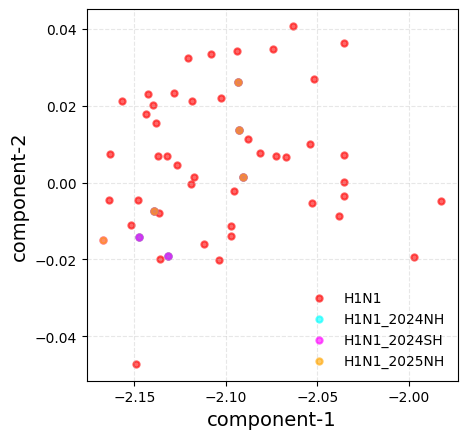

In [69]:
plot_virus_scatter(plot_df[plot_df['type'].isin(['H1N1', 'H1N1_2024NH', 'H1N1_2024SH', 'H1N1_2025NH'])], color_map, save_path='H1N1_evo.png')

### 中心

In [19]:
CDC_df = CDC_data.copy()
CDC_df = CDC_df.loc[(CDC_df['seq_c'].str.len() == 566),:]
CDC_df['Type'] = CDC_df['Type'] + '_CDC'
CNIC_df = CNIC_data.copy()
CNIC_df = CNIC_df.loc[(CNIC_df['seq_c'].str.len() == 566),:]
CNIC_df['Type'] = CNIC_df['Type'] + '_CNIC'

all_df = pd.concat([Crick_df, CDC_df, CNIC_df]).reset_index(drop=True)

In [20]:
vector_CDC = np.stack([np.asarray(emb_dict_CDC['matrix_'+str(HA_name)].max(axis=0)[0].to('cpu')) for HA_name in CDC_df['seq_id_c']])
vector_CNIC = np.stack([np.asarray(emb_dict_CNIC['matrix_'+str(HA_name)].max(axis=0)[0].to('cpu')) for HA_name in CNIC_df['seq_id_c']])
all_vector = np.vstack([vector_Crick, vector_CDC, vector_CNIC])

In [65]:
# all_df.to_csv('Institution_data.csv', index=False)
# np.save("Institution_vectors.npy", all_vector)
all_df = pd.read_csv('Institution_data.csv')
all_vector = np.load('Institution_vectors.npy')

In [51]:
# color_map = {
#         'H1N1': 'red',
#         'H3N2': 'red',
#         'H1N1_CDC': 'cyan',
#         'H3N2_CDC': 'cyan',
#         'H1N1_CNIC': 'magenta',
#         'H3N2_CNIC': 'magenta'
#     }
color_map = {
        'Crick': 'red',
        'CDC': 'cyan',
        'CNIC': 'magenta'
    }

plot_df = cluster_virus(all_df, all_vector, drop_duplicate=True)

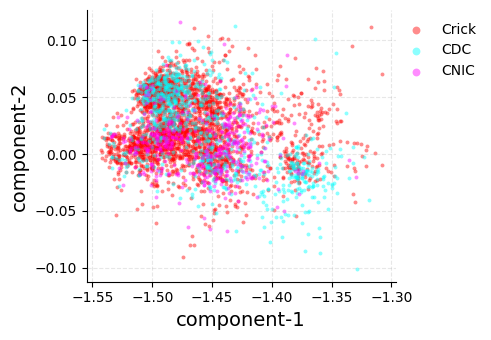

In [107]:
H1N1_ins = plot_df[plot_df['type'].isin(['H1N1', 'H1N1_CDC', 'H1N1_CNIC'])].copy()
H1N1_ins['type'] = H1N1_ins['type'].replace({'H1N1': 'Crick', 'H1N1_CDC': 'CDC', 'H1N1_CNIC': 'CNIC'})
H1N1_ins = H1N1_ins[H1N1_ins['x'] < -1.3]
H1N1_ins = H1N1_ins[H1N1_ins['y'] < 0.12]
H1N1_ins = H1N1_ins[H1N1_ins['virusDate'] <= '2023-08-31']
plot_virus_scatter(H1N1_ins, color_map, save_path='H1N1_ins.svg')

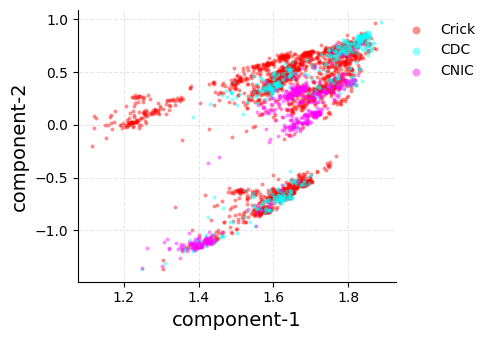

In [108]:
H3N2_ins = plot_df[plot_df['type'].isin(['H3N2', 'H3N2_CDC', 'H3N2_CNIC'])].copy()
H3N2_ins['type'] = H3N2_ins['type'].replace({'H3N2': 'Crick', 'H3N2_CDC': 'CDC', 'H3N2_CNIC': 'CNIC'})
H3N2_ins = H3N2_ins[H3N2_ins['virusDate'] <= '2023-08-31']
H3N2_ins = H3N2_ins[H3N2_ins['x'] > 1.1]
plot_virus_scatter(H3N2_ins, color_map, save_path='H3N2_ins.svg')

## testing

In [ ]:
CDC_data = pd.read_csv('../../data/data_40/CDC_all.csv')
CDC_data['seq_diff_ohe'] = CDC_data['seq_diff_ohe'].apply(ast.literal_eval)
CDC_data = CDC_data.loc[CDC_data['virusDate'] <= '2023-08-31',:]

group_columns = ['seq_a', 'seq_b', 'seq_c', 'seq_d', 'serumPassCat', 'virusPassCat']
agg_dict = {c: 'first' for c in CDC_data.columns if c not in group_columns}
agg_dict['label'] = 'mean'
test_df = CDC_data.groupby(group_columns).agg(agg_dict).reset_index()

In [ ]:
H1N1_label, H1N1_prediction = predict_Adaboost_titer(test_df[test_df['Type'] == 'H1N1'], meta_features, 'Adaboost_H1N1_titer.pkl')
H3N2_label, H3N2_prediction = predict_Adaboost_titer(test_df[test_df['Type'] == 'H3N2'], meta_features, 'Adaboost_H3N2_titer.pkl')

test_df.loc[test_df['Type'] == 'H1N1', 'pred_with_name'] = H1N1_prediction
test_df.loc[test_df['Type'] == 'H3N2', 'pred_with_name'] = H3N2_prediction
result = print_exams(test_df['pred_with_name'], test_df['label'])

MAE: 1.06258
MSE: 2.10216
pearson correlation: 0.75137
spearman correlation: 0.70609
R2_score: 0.50620


In [ ]:
temp_df = test_df.copy()
temp_df.loc[:, 'serumName'] = ''
temp_df.loc[:, 'virusName'] = ''
H1N1_label, H1N1_prediction = predict_Adaboost_titer(temp_df[temp_df['Type'] == 'H1N1'], meta_features, 'Adaboost_H1N1_serum.pkl')
H3N2_label, H3N2_prediction = predict_Adaboost_titer(temp_df[temp_df['Type'] == 'H3N2'], meta_features, 'Adaboost_H3N2_serum.pkl')

test_df.loc[test_df['Type'] == 'H1N1', 'pred_without_name'] = H1N1_prediction
test_df.loc[test_df['Type'] == 'H3N2', 'pred_without_name'] = H3N2_prediction
result = print_exams(test_df['pred_without_name'], test_df['label'])

MAE: 1.07081
MSE: 2.16056
pearson correlation: 0.74549
spearman correlation: 0.69442
R2_score: 0.49248


In [ ]:
test_df.to_csv('../../Figure/Fig2/Adaboost_CDC.csv')

In [ ]:
CDC_data = pd.read_csv('../../data/data_40/CDC_all.csv')
CDC_data['seq_diff_ohe'] = CDC_data['seq_diff_ohe'].apply(ast.literal_eval)
CDC_data = CDC_data.loc[CDC_data['virusDate'] <= '2023-08-31',:]

group_columns = ['seq_a', 'seq_b', 'seq_c', 'seq_d', 'serumPassCat', 'virusPassCat']
agg_dict = {c: 'first' for c in CDC_data.columns if c not in group_columns}
agg_dict['label'] = 'mean'
test_df = CDC_data.groupby(group_columns).agg(agg_dict).reset_index()

In [ ]:
CDC_data = pd.read_csv('../../data/data_40/CDC_all.csv')
CDC_data['seq_diff_ohe'] = CDC_data['seq_diff_ohe'].apply(ast.literal_eval)
CDC_data = CDC_data.loc[CDC_data['virusDate'] <= '2023-08-31',:]

group_columns = ['seq_a', 'seq_b', 'seq_c', 'seq_d', 'serumPassCat', 'virusPassCat']
agg_dict = {c: 'first' for c in CDC_data.columns if c not in group_columns}
agg_dict['label'] = 'mean'
test_df = CDC_data.groupby(group_columns).agg(agg_dict).reset_index()

In [ ]:
CDC_data = pd.read_csv('../../data/data_40/CDC_all.csv')
CDC_data['seq_diff_ohe'] = CDC_data['seq_diff_ohe'].apply(ast.literal_eval)
CDC_data = CDC_data.loc[CDC_data['virusDate'] <= '2023-08-31',:]

group_columns = ['seq_a', 'seq_b', 'seq_c', 'seq_d', 'serumPassCat', 'virusPassCat']
agg_dict = {c: 'first' for c in CDC_data.columns if c not in group_columns}
agg_dict['label'] = 'mean'
test_df = CDC_data.groupby(group_columns).agg(agg_dict).reset_index()

In [ ]:
CDC_data = pd.read_csv('../../data/data_40/CDC_all.csv')
CDC_data['seq_diff_ohe'] = CDC_data['seq_diff_ohe'].apply(ast.literal_eval)
CDC_data = CDC_data.loc[CDC_data['virusDate'] <= '2023-08-31',:]

group_columns = ['seq_a', 'seq_b', 'seq_c', 'seq_d', 'serumPassCat', 'virusPassCat']
agg_dict = {c: 'first' for c in CDC_data.columns if c not in group_columns}
agg_dict['label'] = 'mean'
test_df = CDC_data.groupby(group_columns).agg(agg_dict).reset_index()

In [ ]:
H1N1_label, H1N1_prediction = predict_Adaboost_titer(test_df[test_df['Type'] == 'H1N1'], meta_features, 'Adaboost_H1N1_titer.pkl')
H3N2_label, H3N2_prediction = predict_Adaboost_titer(test_df[test_df['Type'] == 'H3N2'], meta_features, 'Adaboost_H3N2_titer.pkl')

test_df.loc[test_df['Type'] == 'H1N1', 'pred_with_name'] = H1N1_prediction
test_df.loc[test_df['Type'] == 'H3N2', 'pred_with_name'] = H3N2_prediction
result = print_exams(test_df['pred_with_name'], test_df['label'])

MAE: 1.06258
MSE: 2.10216
pearson correlation: 0.75137
spearman correlation: 0.70609
R2_score: 0.50620


In [ ]:
temp_df = test_df.copy()
temp_df.loc[:, 'serumName'] = ''
temp_df.loc[:, 'virusName'] = ''
H1N1_label, H1N1_prediction = predict_Adaboost_titer(temp_df[temp_df['Type'] == 'H1N1'], meta_features, 'Adaboost_H1N1_serum.pkl')
H3N2_label, H3N2_prediction = predict_Adaboost_titer(temp_df[temp_df['Type'] == 'H3N2'], meta_features, 'Adaboost_H3N2_serum.pkl')

test_df.loc[test_df['Type'] == 'H1N1', 'pred_without_name'] = H1N1_prediction
test_df.loc[test_df['Type'] == 'H3N2', 'pred_without_name'] = H3N2_prediction
result = print_exams(test_df['pred_without_name'], test_df['label'])

MAE: 1.07081
MSE: 2.16056
pearson correlation: 0.74549
spearman correlation: 0.69442
R2_score: 0.49248


In [ ]:
test_df.to_csv('../../Figure/Fig2/Adaboost_CDC.csv')

In [ ]:
H1N1_label, H1N1_prediction = predict_Adaboost_titer(test_df[test_df['Type'] == 'H1N1'], meta_features, 'Adaboost_H1N1_titer.pkl')
H3N2_label, H3N2_prediction = predict_Adaboost_titer(test_df[test_df['Type'] == 'H3N2'], meta_features, 'Adaboost_H3N2_titer.pkl')

test_df.loc[test_df['Type'] == 'H1N1', 'pred_with_name'] = H1N1_prediction
test_df.loc[test_df['Type'] == 'H3N2', 'pred_with_name'] = H3N2_prediction
result = print_exams(test_df['pred_with_name'], test_df['label'])

MAE: 1.06258
MSE: 2.10216
pearson correlation: 0.75137
spearman correlation: 0.70609
R2_score: 0.50620


In [ ]:
temp_df = test_df.copy()
temp_df.loc[:, 'serumName'] = ''
temp_df.loc[:, 'virusName'] = ''
H1N1_label, H1N1_prediction = predict_Adaboost_titer(temp_df[temp_df['Type'] == 'H1N1'], meta_features, 'Adaboost_H1N1_serum.pkl')
H3N2_label, H3N2_prediction = predict_Adaboost_titer(temp_df[temp_df['Type'] == 'H3N2'], meta_features, 'Adaboost_H3N2_serum.pkl')

test_df.loc[test_df['Type'] == 'H1N1', 'pred_without_name'] = H1N1_prediction
test_df.loc[test_df['Type'] == 'H3N2', 'pred_without_name'] = H3N2_prediction
result = print_exams(test_df['pred_without_name'], test_df['label'])

MAE: 1.07081
MSE: 2.16056
pearson correlation: 0.74549
spearman correlation: 0.69442
R2_score: 0.49248


In [ ]:
test_df.to_csv('../../Figure/Fig2/Adaboost_CDC.csv')

In [ ]:
H1N1_label, H1N1_prediction = predict_Adaboost_titer(test_df[test_df['Type'] == 'H1N1'], meta_features, 'Adaboost_H1N1_titer.pkl')
H3N2_label, H3N2_prediction = predict_Adaboost_titer(test_df[test_df['Type'] == 'H3N2'], meta_features, 'Adaboost_H3N2_titer.pkl')

test_df.loc[test_df['Type'] == 'H1N1', 'pred_with_name'] = H1N1_prediction
test_df.loc[test_df['Type'] == 'H3N2', 'pred_with_name'] = H3N2_prediction
result = print_exams(test_df['pred_with_name'], test_df['label'])

MAE: 1.06258
MSE: 2.10216
pearson correlation: 0.75137
spearman correlation: 0.70609
R2_score: 0.50620


In [ ]:
temp_df = test_df.copy()
temp_df.loc[:, 'serumName'] = ''
temp_df.loc[:, 'virusName'] = ''
H1N1_label, H1N1_prediction = predict_Adaboost_titer(temp_df[temp_df['Type'] == 'H1N1'], meta_features, 'Adaboost_H1N1_serum.pkl')
H3N2_label, H3N2_prediction = predict_Adaboost_titer(temp_df[temp_df['Type'] == 'H3N2'], meta_features, 'Adaboost_H3N2_serum.pkl')

test_df.loc[test_df['Type'] == 'H1N1', 'pred_without_name'] = H1N1_prediction
test_df.loc[test_df['Type'] == 'H3N2', 'pred_without_name'] = H3N2_prediction
result = print_exams(test_df['pred_without_name'], test_df['label'])

MAE: 1.07081
MSE: 2.16056
pearson correlation: 0.74549
spearman correlation: 0.69442
R2_score: 0.49248


In [ ]:
test_df.to_csv('../../Figure/Fig2/Adaboost_CDC.csv')

In [ ]:
H1N1_label, H1N1_prediction = predict_Adaboost_titer(test_df[test_df['Type'] == 'H1N1'], meta_features, 'Adaboost_H1N1_titer.pkl')
H3N2_label, H3N2_prediction = predict_Adaboost_titer(test_df[test_df['Type'] == 'H3N2'], meta_features, 'Adaboost_H3N2_titer.pkl')

test_df.loc[test_df['Type'] == 'H1N1', 'pred_with_name'] = H1N1_prediction
test_df.loc[test_df['Type'] == 'H3N2', 'pred_with_name'] = H3N2_prediction
result = print_exams(test_df['pred_with_name'], test_df['label'])

MAE: 1.06258
MSE: 2.10216
pearson correlation: 0.75137
spearman correlation: 0.70609
R2_score: 0.50620


In [ ]:
temp_df = test_df.copy()
temp_df.loc[:, 'serumName'] = ''
temp_df.loc[:, 'virusName'] = ''
H1N1_label, H1N1_prediction = predict_Adaboost_titer(temp_df[temp_df['Type'] == 'H1N1'], meta_features, 'Adaboost_H1N1_serum.pkl')
H3N2_label, H3N2_prediction = predict_Adaboost_titer(temp_df[temp_df['Type'] == 'H3N2'], meta_features, 'Adaboost_H3N2_serum.pkl')

test_df.loc[test_df['Type'] == 'H1N1', 'pred_without_name'] = H1N1_prediction
test_df.loc[test_df['Type'] == 'H3N2', 'pred_without_name'] = H3N2_prediction
result = print_exams(test_df['pred_without_name'], test_df['label'])

MAE: 1.07081
MSE: 2.16056
pearson correlation: 0.74549
spearman correlation: 0.69442
R2_score: 0.49248


In [ ]:
test_df.to_csv('../../Figure/Fig2/Adaboost_CDC.csv')

In [ ]:
CDC_data = pd.read_csv('../../data/data_40/CDC_all.csv')
CDC_data['seq_diff_ohe'] = CDC_data['seq_diff_ohe'].apply(ast.literal_eval)
CDC_data = CDC_data.loc[CDC_data['virusDate'] <= '2023-08-31',:]

group_columns = ['seq_a', 'seq_b', 'seq_c', 'seq_d', 'serumPassCat', 'virusPassCat']
agg_dict = {c: 'first' for c in CDC_data.columns if c not in group_columns}
agg_dict['label'] = 'mean'
test_df = CDC_data.groupby(group_columns).agg(agg_dict).reset_index()

In [ ]:
CDC_data = pd.read_csv('../../data/data_40/CDC_all.csv')
CDC_data['seq_diff_ohe'] = CDC_data['seq_diff_ohe'].apply(ast.literal_eval)
CDC_data = CDC_data.loc[CDC_data['virusDate'] <= '2023-08-31',:]

group_columns = ['seq_a', 'seq_b', 'seq_c', 'seq_d', 'serumPassCat', 'virusPassCat']
agg_dict = {c: 'first' for c in CDC_data.columns if c not in group_columns}
agg_dict['label'] = 'mean'
test_df = CDC_data.groupby(group_columns).agg(agg_dict).reset_index()

In [ ]:
CDC_data = pd.read_csv('../../data/data_40/CDC_all.csv')
CDC_data['seq_diff_ohe'] = CDC_data['seq_diff_ohe'].apply(ast.literal_eval)
CDC_data = CDC_data.loc[CDC_data['virusDate'] <= '2023-08-31',:]

group_columns = ['seq_a', 'seq_b', 'seq_c', 'seq_d', 'serumPassCat', 'virusPassCat']
agg_dict = {c: 'first' for c in CDC_data.columns if c not in group_columns}
agg_dict['label'] = 'mean'
test_df = CDC_data.groupby(group_columns).agg(agg_dict).reset_index()

In [ ]:
H1N1_label, H1N1_prediction = predict_Adaboost_titer(test_df[test_df['Type'] == 'H1N1'], meta_features, 'Adaboost_H1N1_titer.pkl')
H3N2_label, H3N2_prediction = predict_Adaboost_titer(test_df[test_df['Type'] == 'H3N2'], meta_features, 'Adaboost_H3N2_titer.pkl')

test_df.loc[test_df['Type'] == 'H1N1', 'pred_with_name'] = H1N1_prediction
test_df.loc[test_df['Type'] == 'H3N2', 'pred_with_name'] = H3N2_prediction
result = print_exams(test_df['pred_with_name'], test_df['label'])

MAE: 1.06258
MSE: 2.10216
pearson correlation: 0.75137
spearman correlation: 0.70609
R2_score: 0.50620


In [ ]:
temp_df = test_df.copy()
temp_df.loc[:, 'serumName'] = ''
temp_df.loc[:, 'virusName'] = ''
H1N1_label, H1N1_prediction = predict_Adaboost_titer(temp_df[temp_df['Type'] == 'H1N1'], meta_features, 'Adaboost_H1N1_serum.pkl')
H3N2_label, H3N2_prediction = predict_Adaboost_titer(temp_df[temp_df['Type'] == 'H3N2'], meta_features, 'Adaboost_H3N2_serum.pkl')

test_df.loc[test_df['Type'] == 'H1N1', 'pred_without_name'] = H1N1_prediction
test_df.loc[test_df['Type'] == 'H3N2', 'pred_without_name'] = H3N2_prediction
result = print_exams(test_df['pred_without_name'], test_df['label'])

MAE: 1.07081
MSE: 2.16056
pearson correlation: 0.74549
spearman correlation: 0.69442
R2_score: 0.49248


In [ ]:
test_df.to_csv('../../Figure/Fig2/Adaboost_CDC.csv')

In [ ]:
H1N1_label, H1N1_prediction = predict_Adaboost_titer(test_df[test_df['Type'] == 'H1N1'], meta_features, 'Adaboost_H1N1_titer.pkl')
H3N2_label, H3N2_prediction = predict_Adaboost_titer(test_df[test_df['Type'] == 'H3N2'], meta_features, 'Adaboost_H3N2_titer.pkl')

test_df.loc[test_df['Type'] == 'H1N1', 'pred_with_name'] = H1N1_prediction
test_df.loc[test_df['Type'] == 'H3N2', 'pred_with_name'] = H3N2_prediction
result = print_exams(test_df['pred_with_name'], test_df['label'])

MAE: 1.06258
MSE: 2.10216
pearson correlation: 0.75137
spearman correlation: 0.70609
R2_score: 0.50620


In [ ]:
temp_df = test_df.copy()
temp_df.loc[:, 'serumName'] = ''
temp_df.loc[:, 'virusName'] = ''
H1N1_label, H1N1_prediction = predict_Adaboost_titer(temp_df[temp_df['Type'] == 'H1N1'], meta_features, 'Adaboost_H1N1_serum.pkl')
H3N2_label, H3N2_prediction = predict_Adaboost_titer(temp_df[temp_df['Type'] == 'H3N2'], meta_features, 'Adaboost_H3N2_serum.pkl')

test_df.loc[test_df['Type'] == 'H1N1', 'pred_without_name'] = H1N1_prediction
test_df.loc[test_df['Type'] == 'H3N2', 'pred_without_name'] = H3N2_prediction
result = print_exams(test_df['pred_without_name'], test_df['label'])

MAE: 1.07081
MSE: 2.16056
pearson correlation: 0.74549
spearman correlation: 0.69442
R2_score: 0.49248


In [ ]:
test_df.to_csv('../../Figure/Fig2/Adaboost_CDC.csv')

In [ ]:
H1N1_label, H1N1_prediction = predict_Adaboost_titer(test_df[test_df['Type'] == 'H1N1'], meta_features, 'Adaboost_H1N1_titer.pkl')
H3N2_label, H3N2_prediction = predict_Adaboost_titer(test_df[test_df['Type'] == 'H3N2'], meta_features, 'Adaboost_H3N2_titer.pkl')

test_df.loc[test_df['Type'] == 'H1N1', 'pred_with_name'] = H1N1_prediction
test_df.loc[test_df['Type'] == 'H3N2', 'pred_with_name'] = H3N2_prediction
result = print_exams(test_df['pred_with_name'], test_df['label'])

MAE: 1.06258
MSE: 2.10216
pearson correlation: 0.75137
spearman correlation: 0.70609
R2_score: 0.50620


In [ ]:
temp_df = test_df.copy()
temp_df.loc[:, 'serumName'] = ''
temp_df.loc[:, 'virusName'] = ''
H1N1_label, H1N1_prediction = predict_Adaboost_titer(temp_df[temp_df['Type'] == 'H1N1'], meta_features, 'Adaboost_H1N1_serum.pkl')
H3N2_label, H3N2_prediction = predict_Adaboost_titer(temp_df[temp_df['Type'] == 'H3N2'], meta_features, 'Adaboost_H3N2_serum.pkl')

test_df.loc[test_df['Type'] == 'H1N1', 'pred_without_name'] = H1N1_prediction
test_df.loc[test_df['Type'] == 'H3N2', 'pred_without_name'] = H3N2_prediction
result = print_exams(test_df['pred_without_name'], test_df['label'])

MAE: 1.07081
MSE: 2.16056
pearson correlation: 0.74549
spearman correlation: 0.69442
R2_score: 0.49248


In [ ]:
test_df.to_csv('../../Figure/Fig2/Adaboost_CDC.csv')

In [88]:
import plotly.express as px
import pandas as pd


df = pd.DataFrame(X_3d, columns=['x', 'y', 'z'])
df['cluster'] = labels.astype(str)
df['type'] = all_df['Type'].tolist()
df['virusDate'] = all_df['virusDate'].tolist()
df['virusIslID'] = all_df['virusIslID'].tolist()
# 1. 确保 type 只有两类
# assert df['type'].nunique() == 4, 'type 必须是恰好两类'

# 2. 手动指定颜色：红 & 蓝
# color_map = {'H1N1': 'red',   # 把 'class_A' 换成你实际的第一类名称
#              'H3N2': 'blue',
#              '43': 'yellow'}  # 把 'class_B' 换成第二类名称
# color_map = {'H1N1': 'red',   # 把 'class_A' 换成你实际的第一类名称
#              'H3N2': 'blue',
        #      'H1N1_CDC': 'yellow',
        #      'H3N2_CDC': 'green',
        #      'H1N1_43': 'rgba(125,125,125,10)',
        #      'H3N2_43': 'rgba(255,255,0,1)'}  # 把 'class_B' 换成第二类名称
color_map = {
    'H1N1': 'rgba(220,  20,  60, 1)',   # 鲜红（实色）
    'H3N2': 'rgba(220,  20,  60, 1)',   # 深蓝（实色）

    # 'H1N1_CDC': 'rgba(  0,  90, 181, 0.1)',
    # 'H3N2_CDC': 'rgba(  0,  90, 181, 0.1)',

    # 'H1N1_CNIC': 'rgba(255, 255, 0, 0.10)',
    # 'H3N2_CNIC': 'rgba(255, 255, 0, 0.10)',

    'H1N1_2024NH': 'rgba(  0, 255, 255, 0.10)', # 霓虹青 10 % 不透明
    'H3N2_2024NH': 'rgba(  0, 255, 255, 0.10)',

    'H1N1_2024SH': 'rgba(255,   0, 255, 0.10)', # 霓虹紫 10 % 不透明
    'H3N2_2024SH': 'rgba(255,   0, 255, 0.10)',

    'H1N1_2025NH': 'rgba(0,   255, 255, 0.10)', # 霓虹紫 10 % 不透明
    'H3N2_2025NH': 'rgba(0,   255, 255, 0.10)'
}

fig = px.scatter_3d(
        df, x='x', y='y', z='z',
        color='type',
        color_discrete_map=color_map,
        opacity=0.8,
        hover_data={'virusDate': True,   # 显示日期
                    'cluster': True,
                    'virusIslID': True},  
        title='3D clustering (Red vs Blue)'
)

fig.update_traces(marker=dict(size=4))
fig.show()

## 2024NH

In [ ]:
model = torch.load('../../trained_model/1.7_Artificial_back/2025-08-19_17-43-32.pth', weights_only=False, map_location=device)
Crick41 = Crick_41.copy()

group_columns = ['seq_a', 'seq_b', 'seq_c', 'seq_d', 'serumPassCat', 'virusPassCat']
agg_dict = {c: 'first' for c in Crick41.columns if c not in group_columns}
agg_dict['label'] = 'mean'
Crick41_final = Crick41.groupby(group_columns).agg(agg_dict).reset_index()

Dataloader_41 = DataLoader(fluProfiler_Dataset(Crick41_final), batch_size=10, shuffle=False)

prediction_ls = []
reference_ls = []
logits_ls = []
loss_ls_valid = []
model.eval()
for batch in Dataloader_41:
    emb_file_name_a, emb_file_name_b, emb_file_name_c, emb_file_name_d, strainPassCats, labels = batch
    
    matrixs_a, masks_a = generate_matrix([emb_dict_41[key] for key in emb_file_name_a])
    matrixs_b, masks_b = generate_matrix([emb_dict_41[key] for key in emb_file_name_b])
    matrixs_c, masks_c = generate_matrix([emb_dict_41[key] for key in emb_file_name_c])
    matrixs_d, masks_d = generate_matrix([emb_dict_41[key] for key in emb_file_name_d])

    matrixs_a, matrixs_b, matrixs_c, matrixs_d = matrixs_a.to(device), matrixs_b.to(device), matrixs_c.to(device), matrixs_d.to(device)
    masks_a = masks_a.to(device)
    masks_b = masks_b.to(device)
    masks_c = masks_c.to(device)
    masks_d = masks_d.to(device)

    strainPassCats = strainPassCats.to(device)

    labels = labels.to(device)
    with torch.no_grad():
        loss, logits, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c, 
                                        matrices_d=matrixs_d, matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b, 
                                        matrix_attention_masks_c=masks_c, matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats, 
                                        labels=labels)

    loss_ls_valid.append(loss.item())
    logits_ls.append(logits.tolist())
    prediction_ls = prediction_ls + output.view(-1).tolist()
    reference_ls = reference_ls + labels.tolist()

temp = Crick41_final.copy()
temp['prediction'] = prediction_ls

result = print_exams(reference_ls, prediction_ls)

MAE: 0.67645
MSE: 0.74275
pearson correlation: 0.70152
spearman correlation: 0.71789
R2_score: 0.08059


In [ ]:
temp.to_csv('../../Figure/Fig2/fluProfiler_41.csv', index=False)

: 

## 在CDC上的性能测试

In [ ]:
model = torch.load('../../trained_model/1.7_Artificial_back/2025-08-19_17-43-32.pth', weights_only=False, map_location=device)
CDC = CDC_data.copy()
CDC = CDC.loc[CDC['virusDate'] <= '2023-08-31',:]

group_columns = ['seq_a', 'seq_b', 'seq_c', 'seq_d', 'serumPassCat', 'virusPassCat']
agg_dict = {c: 'first' for c in CDC.columns if c not in group_columns}
agg_dict['label'] = 'mean'
CDC_final = CDC.groupby(group_columns).agg(agg_dict).reset_index()

Dataloader_CDC = DataLoader(fluProfiler_Dataset(CDC_final), batch_size=10, shuffle=False)

prediction_ls = []
reference_ls = []
logits_ls = []
loss_ls_valid = []
model.eval()
for batch in Dataloader_CDC:
    emb_file_name_a, emb_file_name_b, emb_file_name_c, emb_file_name_d, strainPassCats, labels = batch
    
    matrixs_a, masks_a = generate_matrix([emb_dict_CDC[key] for key in emb_file_name_a])
    matrixs_b, masks_b = generate_matrix([emb_dict_CDC[key] for key in emb_file_name_b])
    matrixs_c, masks_c = generate_matrix([emb_dict_CDC[key] for key in emb_file_name_c])
    matrixs_d, masks_d = generate_matrix([emb_dict_CDC[key] for key in emb_file_name_d])

    matrixs_a, matrixs_b, matrixs_c, matrixs_d = matrixs_a.to(device), matrixs_b.to(device), matrixs_c.to(device), matrixs_d.to(device)
    masks_a = masks_a.to(device)
    masks_b = masks_b.to(device)
    masks_c = masks_c.to(device)
    masks_d = masks_d.to(device)

    strainPassCats = strainPassCats.to(device)

    labels = labels.to(device)
    with torch.no_grad():
        loss, logits, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c, 
                                        matrices_d=matrixs_d, matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b, 
                                        matrix_attention_masks_c=masks_c, matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats, 
                                        labels=labels)

    loss_ls_valid.append(loss.item())
    logits_ls.append(logits.tolist())
    prediction_ls = prediction_ls + output.view(-1).tolist()
    reference_ls = reference_ls + labels.tolist()

temp = CDC_final.copy()
temp['prediction'] = prediction_ls

# H1N1_result = print_exams(temp[temp['Type'] == 'H1N1']['label'], temp[temp['Type'] == 'H1N1']['prediction']) 
# H3N2_result = print_exams(temp[temp['Type'] == 'H3N2']['label'], temp[temp['Type'] == 'H3N2']['prediction']) 
result = print_exams(reference_ls, prediction_ls)

MAE: 1.08353
MSE: 2.14430
pearson correlation: 0.73352
spearman correlation: 0.68283
R2_score: 0.37807


In [ ]:
temp.to_csv('../../Figure/Fig2/fluProfiler_CDC.csv', index=False)

## 在CNIC上的性能测试

In [ ]:
model = torch.load('../../trained_model/1.7_Artificial_back/2025-08-19_17-43-32.pth', weights_only=False, map_location=device)
CNIC = pd.read_csv('../../data/data_40/CNIC_all.csv')
CNIC = CNIC.loc[CNIC['virusDate'] <= '2023-08-31',:]

group_columns = ['seq_a', 'seq_b', 'seq_c', 'seq_d', 'serumPassCat', 'virusPassCat']
agg_dict = {c: 'first' for c in CNIC.columns if c not in group_columns}
agg_dict['label'] = 'mean'
CNIC_final = CNIC.groupby(group_columns).agg(agg_dict).reset_index()

Dataloader_CNIC = DataLoader(fluProfiler_Dataset(CNIC_final), batch_size=10, shuffle=False)

prediction_ls = []
reference_ls = []
logits_ls = []
loss_ls_valid = []
model.eval()
for batch in Dataloader_CNIC:
    emb_file_name_a, emb_file_name_b, emb_file_name_c, emb_file_name_d, strainPassCats, labels = batch
    
    matrixs_a, masks_a = generate_matrix([emb_dict_CNIC[key] for key in emb_file_name_a])
    matrixs_b, masks_b = generate_matrix([emb_dict_CNIC[key] for key in emb_file_name_b])
    matrixs_c, masks_c = generate_matrix([emb_dict_CNIC[key] for key in emb_file_name_c])
    matrixs_d, masks_d = generate_matrix([emb_dict_CNIC[key] for key in emb_file_name_d])

    matrixs_a, matrixs_b, matrixs_c, matrixs_d = matrixs_a.to(device), matrixs_b.to(device), matrixs_c.to(device), matrixs_d.to(device)
    masks_a = masks_a.to(device)
    masks_b = masks_b.to(device)
    masks_c = masks_c.to(device)
    masks_d = masks_d.to(device)

    strainPassCats = strainPassCats.to(device)

    labels = labels.to(device)
    with torch.no_grad():
        loss, logits, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c, 
                                        matrices_d=matrixs_d, matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b, 
                                        matrix_attention_masks_c=masks_c, matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats, 
                                        labels=labels)

    loss_ls_valid.append(loss.item())
    logits_ls.append(logits.tolist())
    prediction_ls = prediction_ls + output.view(-1).tolist()
    reference_ls = reference_ls + labels.tolist()

temp = CNIC_final.copy()
temp['prediction'] = prediction_ls

H1N1_result = print_exams(temp[temp['Type'] == 'H1N1']['label'], temp[temp['Type'] == 'H1N1']['prediction']) 
H3N2_result = print_exams(temp[temp['Type'] == 'H3N2']['label'], temp[temp['Type'] == 'H3N2']['prediction']) 
result = print_exams(reference_ls, prediction_ls)

MAE: 1.26080
MSE: 2.91992
pearson correlation: 0.76834
spearman correlation: 0.59022
R2_score: -0.03245
MAE: 1.31243
MSE: 2.82123
pearson correlation: 0.53699
spearman correlation: 0.53287
R2_score: -0.32345
MAE: 1.29112
MSE: 2.86195
pearson correlation: 0.68300
spearman correlation: 0.70597
R2_score: 0.02631


In [ ]:
temp.to_csv('../../Figure/Fig2/fluProfiler_CNIC.csv', index=False)

In [8]:
temp = CNIC_final.copy()
temp['prediction'] = prediction_ls

H1N1_result = print_exams(temp[temp['Type'] == 'H1N1']['label'], temp[temp['Type'] == 'H1N1']['prediction']) 
H3N2_result = print_exams(temp[temp['Type'] == 'H3N2']['label'], temp[temp['Type'] == 'H3N2']['prediction']) 

MAE: 0.91296
MSE: 1.46352
pearson correlation: 0.84837
spearman correlation: 0.59905
R2_score: 0.55319
MAE: 1.33513
MSE: 2.96646
pearson correlation: 0.50213
spearman correlation: 0.49727
R2_score: -0.68280


In [ ]:
Crick_41 = pd.read_csv('../../data/data_40/Crick_41.csv')
group_columns = ['seq_a', 'seq_b', 'seq_c', 'seq_d', 'serumPassCat', 'virusPassCat']
agg_dict = {c: 'first' for c in Crick_41.columns if c not in group_columns}
agg_dict['label'] = 'mean'
Crick_41_final = Crick_41.groupby(group_columns).agg(agg_dict).reset_index()

In [ ]:
Crick_42 = pd.read_csv('../../data/data_40/Crick_42.csv')
group_columns = ['seq_a', 'seq_b', 'seq_c', 'seq_d', 'serumPassCat', 'virusPassCat']
agg_dict = {c: 'first' for c in Crick_41.columns if c not in group_columns}
agg_dict['label'] = 'mean'
Crick_42_final = Crick_42.groupby(group_columns).agg(agg_dict).reset_index()

In [ ]:
Crick_43 = pd.read_csv('../../data/data_40/Crick_43.csv')
Crick_43['serumPassCat'] = Crick_43['serumPassCat'].map({'EGG': '<EGG>', 'CELL': '<CELL>'})
Crick_43['virusPassCat'] = Crick_43['virusPassCat'].map({'EGG': '<EGG>', 'CELL': '<CELL>'})
group_columns = ['seq_a', 'seq_b', 'seq_c', 'seq_d', 'serumPassCat', 'virusPassCat']
agg_dict = {c: 'first' for c in Crick_41.columns if c not in group_columns}
agg_dict['label'] = 'mean'
Crick_43_final = Crick_43.groupby(group_columns).agg(agg_dict).reset_index()

In [5]:
Dataloader_41 = DataLoader(fluProfiler_Dataset(Crick_41_final), batch_size=10, shuffle=False)
# Dataloader_42 = DataLoader(fluProfiler_Dataset(Crick_42_final), batch_size=10, shuffle=False)
# Dataloader_43 = DataLoader(fluProfiler_Dataset(Crick_43_final), batch_size=10, shuffle=False)

In [ ]:
model = torch.load('../../trained_model/1.7_Artificial_back/2025-08-19_17-43-32.pth', weights_only=False, map_location=device)

prediction_ls = []
reference_ls = []
logits_ls = []
loss_ls_valid = []
model.eval()
for batch in Dataloader_41:
    emb_file_name_a, emb_file_name_b, emb_file_name_c, emb_file_name_d, strainPassCats, labels = batch
    
    matrixs_a, masks_a = generate_matrix([emb_dict_41[key] for key in emb_file_name_a])
    matrixs_b, masks_b = generate_matrix([emb_dict_41[key] for key in emb_file_name_b])
    matrixs_c, masks_c = generate_matrix([emb_dict_41[key] for key in emb_file_name_c])
    matrixs_d, masks_d = generate_matrix([emb_dict_41[key] for key in emb_file_name_d])

    matrixs_a, matrixs_b, matrixs_c, matrixs_d = matrixs_a.to(device), matrixs_b.to(device), matrixs_c.to(device), matrixs_d.to(device)
    masks_a = masks_a.to(device)
    masks_b = masks_b.to(device)
    masks_c = masks_c.to(device)
    masks_d = masks_d.to(device)

    strainPassCats = strainPassCats.to(device)

    labels = labels.to(device)
    with torch.no_grad():
        loss, logits, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c, 
                                        matrices_d=matrixs_d, matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b, 
                                        matrix_attention_masks_c=masks_c, matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats, 
                                        labels=labels)

    loss_ls_valid.append(loss.item())
    logits_ls.append(logits.tolist())
    prediction_ls = prediction_ls + output.view(-1).tolist()
    reference_ls = reference_ls + labels.tolist()

result = print_exams(reference_ls, prediction_ls)

MAE: 0.67645
MSE: 0.74275
pearson correlation: 0.70152
spearman correlation: 0.71789
R2_score: 0.08059


In [ ]:
Crick_41_final['prediction'] = prediction_ls
Crick_41_final.to_csv('../../Figure/Fig2/fluProfiler_41.csv', index=False)

In [ ]:
prediction_ls = []
reference_ls = []
logits_ls = []
loss_ls_valid = []
model.eval()
for batch in Dataloader_42:
    emb_file_name_a, emb_file_name_b, emb_file_name_c, emb_file_name_d, strainPassCats, labels = batch
    
    matrixs_a, masks_a = generate_matrix([emb_dict_42[key] for key in emb_file_name_a])
    matrixs_b, masks_b = generate_matrix([emb_dict_42[key] for key in emb_file_name_b])
    matrixs_c, masks_c = generate_matrix([emb_dict_42[key] for key in emb_file_name_c])
    matrixs_d, masks_d = generate_matrix([emb_dict_42[key] for key in emb_file_name_d])

    matrixs_a, matrixs_b, matrixs_c, matrixs_d = matrixs_a.to(device), matrixs_b.to(device), matrixs_c.to(device), matrixs_d.to(device)
    masks_a = masks_a.to(device)
    masks_b = masks_b.to(device)
    masks_c = masks_c.to(device)
    masks_d = masks_d.to(device)

    strainPassCats = strainPassCats.to(device)

    labels = labels.to(device)
    with torch.no_grad():
        loss, logits, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c, 
                                        matrices_d=matrixs_d, matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b, 
                                        matrix_attention_masks_c=masks_c, matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats, 
                                        labels=labels)

    loss_ls_valid.append(loss.item())
    logits_ls.append(logits.tolist())
    prediction_ls = prediction_ls + output.view(-1).tolist()
    reference_ls = reference_ls + labels.tolist()

result = print_exams(reference_ls, prediction_ls)

MAE: 1.04487
MSE: 2.16915
pearson correlation: 0.26942
spearman correlation: 0.26062
R2_score: -3.50363


In [ ]:
prediction_ls = []
reference_ls = []
logits_ls = []
loss_ls_valid = []
model.eval()
for batch in Dataloader_43:
    emb_file_name_a, emb_file_name_b, emb_file_name_c, emb_file_name_d, strainPassCats, labels = batch
    
    matrixs_a, masks_a = generate_matrix([emb_dict_43[key] for key in emb_file_name_a])
    matrixs_b, masks_b = generate_matrix([emb_dict_43[key] for key in emb_file_name_b])
    matrixs_c, masks_c = generate_matrix([emb_dict_43[key] for key in emb_file_name_c])
    matrixs_d, masks_d = generate_matrix([emb_dict_43[key] for key in emb_file_name_d])

    matrixs_a, matrixs_b, matrixs_c, matrixs_d = matrixs_a.to(device), matrixs_b.to(device), matrixs_c.to(device), matrixs_d.to(device)
    masks_a = masks_a.to(device)
    masks_b = masks_b.to(device)
    masks_c = masks_c.to(device)
    masks_d = masks_d.to(device)

    strainPassCats = strainPassCats.to(device)

    labels = labels.to(device)
    with torch.no_grad():
        loss, logits, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c, 
                                        matrices_d=matrixs_d, matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b, 
                                        matrix_attention_masks_c=masks_c, matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats, 
                                        labels=labels)

    loss_ls_valid.append(loss.item())
    logits_ls.append(logits.tolist())
    prediction_ls = prediction_ls + output.view(-1).tolist()
    reference_ls = reference_ls + labels.tolist()

result = print_exams(reference_ls, prediction_ls)

MAE: 1.20519
MSE: 2.76897
pearson correlation: 0.03427
spearman correlation: -0.00564
R2_score: -7.70318


## Vaccination

In [ ]:
Crick_all = pd.read_csv('../../data/data_40/all.csv')

In [193]:
Crick_serum = Crick_all[['seq_id_a', 'seq_id_b', 'seq_a', 'seq_b', 'serumPassCat', 'serumName', 'serumDate', 'serumIslID']].drop_duplicates().copy()
early_vac_serum = Crick_serum[Crick_serum['serumName'] == 'A/DARWIN/9/2021']
early_vac_serum.loc[:, 'seq_id_a'] = early_vac_serum['seq_id_a'].copy() + '_early'
early_vac_serum.loc[:, 'seq_id_b'] = early_vac_serum['seq_id_b'].copy() + '_early'

In [ ]:
Vaccine = pd.read_csv('../../data/data_40/Vaccination.csv')
Vaccine['label'] = Vaccine['HI_Dist']
group_columns = ['seq_a', 'seq_b', 'seq_c', 'seq_d', 'serumPassCat', 'virusPassCat']
agg_dict = {c: 'first' for c in Crick_41.columns if c not in group_columns}
agg_dict['label'] = 'mean'
Vaccine_final = Vaccine.groupby(group_columns).agg(agg_dict).reset_index()

In [195]:
serum = Vaccine_final[['seq_id_a', 'seq_id_b', 'seq_a', 'seq_b', 'serumPassCat', 'serumName']].drop_duplicates().copy()
serum = pd.concat([serum, early_vac_serum])
virus = Vaccine_final[['seq_id_c', 'seq_id_d', 'seq_c', 'seq_d', 'virusPassCat', 'virusName']].drop_duplicates().copy()
Vaccine_artificial = serum.merge(virus, how='cross')
Vaccine_artificial['label'] = 0

In [196]:
Dataloader_Vaccine = DataLoader(fluProfiler_Dataset(Vaccine_artificial), batch_size=10, shuffle=False)

In [ ]:
model = torch.load('../../trained_model/1.7_Artificial_back/2025-08-19_17-43-32.pth', weights_only=False, map_location=device)

In [ ]:
emb_dict_vac = load_embedding('../../data/data_40/embedding_vac')

Loading tensor: 100%|██████████| 246/246 [00:09<00:00, 27.23file/s]


In [ ]:
sequence_names = pd.concat([early_vac_serum['seq_id_a'], early_vac_serum['seq_id_b']]).str.replace('_early', '').unique().tolist()
sequence_names = ['matrix_' + item + '.pt' for item in sequence_names]
emb_dict_early_vac = load_embedding('../../data/data_40/embedding_Crick', sequence_names)
emb_dict_early_vac = {key+'_early': value for key, value in emb_dict_early_vac.items()}

Loading tensor: 100%|██████████| 3/3 [00:00<00:00, 27.44file/s]


In [210]:
emb_dict_vac = emb_dict_vac | emb_dict_early_vac

In [211]:
prediction_ls = []
reference_ls = []
logits_ls = []
loss_ls_valid = []
model.eval()
for batch in Dataloader_Vaccine:
    emb_file_name_a, emb_file_name_b, emb_file_name_c, emb_file_name_d, strainPassCats, labels = batch
    
    matrixs_a, masks_a = generate_matrix([emb_dict_vac[key] for key in emb_file_name_a])
    matrixs_b, masks_b = generate_matrix([emb_dict_vac[key] for key in emb_file_name_b])
    matrixs_c, masks_c = generate_matrix([emb_dict_vac[key] for key in emb_file_name_c])
    matrixs_d, masks_d = generate_matrix([emb_dict_vac[key] for key in emb_file_name_d])

    matrixs_a, matrixs_b, matrixs_c, matrixs_d = matrixs_a.to(device), matrixs_b.to(device), matrixs_c.to(device), matrixs_d.to(device)
    masks_a = masks_a.to(device)
    masks_b = masks_b.to(device)
    masks_c = masks_c.to(device)
    masks_d = masks_d.to(device)

    strainPassCats = strainPassCats.to(device)

    labels = labels.to(device)
    with torch.no_grad():
        loss, logits, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c, 
                                        matrices_d=matrixs_d, matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b, 
                                        matrix_attention_masks_c=masks_c, matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats, 
                                        labels=labels)

    loss_ls_valid.append(loss.item())
    logits_ls.append(logits.tolist())
    prediction_ls = prediction_ls + output.view(-1).tolist()
    reference_ls = reference_ls + labels.tolist()

result = print_exams(reference_ls, prediction_ls)

MAE: 1.14083
MSE: 1.96859
pearson correlation: nan
spearman correlation: nan
R2_score: -1.40237


/mnt/zzbnew/peixunban/chenyihao/fluProfiler_source/src/Section3_ActiveLearning/../utilities.py:72: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  MAE, MSE, Pearson, Spearman, R2 = mean_absolute_error(O, P), mean_squared_error(O, P), pearsonr(O, P), spearmanr(O, P), r2_score(O, P)


In [212]:
Vaccine_artificial['prediction'] = prediction_ls

In [220]:
# 数据展开代码
if 'prediction' in Vaccine_artificial.columns:
    # 定义索引A和索引B的列
    index_a_cols = ['seq_a', 'seq_b', 'serumPassCat', 'serumName']
    index_b_cols = ['seq_c', 'seq_d', 'virusPassCat', 'virusName']
    
    # 需要保留的列
    # preserve_cols = ['serumName', 'virusName', 'serumDate', 'virusDate', 'serumIslID', 'virusIslID']
    preserve_cols = ['serumName', 'virusName']
    
    # 检查所有需要的列是否存在
    missing_cols = []
    for col in index_a_cols + index_b_cols + preserve_cols + ['prediction']:
        if col not in Vaccine_artificial.columns:
            missing_cols.append(col)
    
    if missing_cols:
        print(f"缺少以下列: {missing_cols}")
    else:
        # 创建展开后的数据
        expanded_data = []
        
        for idx, row in Vaccine_artificial.iterrows():
            # 创建索引A的组合
            index_a = tuple(row[col] for col in index_a_cols)
            
            # 创建索引B的组合  
            index_b = tuple(row[col] for col in index_b_cols)
            
            # 创建新行
            new_row = {
                'index_a': str(index_a),
                'index_b': str(index_b),
                'prediction': row['prediction']
            }
            
            # 添加保留的列
            for col in preserve_cols:
                new_row[col] = row[col]
            
            expanded_data.append(new_row)
        
        # 转换为DataFrame
        expanded_df = pd.DataFrame(expanded_data)
        
        print(f"展开后数据形状: {expanded_df.shape}")
        print(f"展开后数据列名: {expanded_df.columns.tolist()}")
        


展开后数据形状: (2816, 5)
展开后数据列名: ['index_a', 'index_b', 'prediction', 'serumName', 'virusName']


In [214]:
serum_df = expanded_df[['index_a', 'serumName']]

In [227]:
def convert_to_pivot_with_serum_names(expand_df, serum_df, preserve_metadata=True):
    """
    将expand_df转换为透视表，列名为serumName
    
    参数:
    expand_df: 原始DataFrame
    serum_df: 包含index_a和serumName映射的DataFrame
    preserve_metadata: 是否保留其他列信息
    
    返回:
    pivot_df: 列名为serumName的透视表
    """
    
    print("=== 转换为带serumName的透视表 ===")
    
    # 创建index_a到serumName的映射
    serum_mapping = dict(zip(serum_df['index_a'], serum_df['serumName']))
    print(f"创建了{len(serum_mapping)}个映射关系")
    
    # 创建透视表
    pivot_df = expand_df.pivot_table(
        index='index_b',
        columns='index_a', 
        values='prediction',
        aggfunc='first',
        fill_value=None
    ).reset_index()
    
    # 重命名列为serumName
    columns_to_rename = {}
    for col in pivot_df.columns:
        if col != 'index_b':  # 保留index_b列
            if col in serum_mapping:
                columns_to_rename[col] = serum_mapping[col]
            else:
                columns_to_rename[col] = f"Unknown_{col}"
    
    pivot_df = pivot_df.rename(columns=columns_to_rename)
    
    # 保留其他列信息（如果需要）
    if preserve_metadata:
        other_cols = [col for col in expand_df.columns 
                      if col not in ['index_a', 'index_b', 'prediction']]
        
        for col in other_cols:
            col_values = expand_df.groupby('index_b')[col].first().reset_index()
            col_values.columns = ['index_b', col]
            pivot_df = pivot_df.merge(col_values, on='index_b', how='left')
    
    print(f"转换完成！形状: {pivot_df.shape}")
    return pivot_df

In [228]:
pivot_df_with_serum = convert_to_pivot_with_serum_names(expanded_df, serum_df)

=== 转换为带serumName的透视表 ===
创建了15个映射关系
转换完成！形状: (176, 18)


In [217]:
pivot_df_with_serum.columns

Index(['index_b', 'A/ALBANIA/289813/2022', 'A/SYDNEY/878/2023',
       'A/THAILAND/08/2022', 'A/MASSACHUSETTS/18/2022',
       'A/BRANDENBURG/15/2022', 'A/SYDNEY/856/2023', 'A/CALIFORNIA/122/2022',
       'A/STOCKHOLM/5/2021', 'A/DARWIN/9/2021', 'A/DARWIN/9/2021',
       'A/CATALONIA/NSVH161512067/2022', 'A/MONTANA/08/2023',
       'A/MONTANA/08/2023', 'A/SWITZERLAND/28719/2022', 'A/THURINGEN/10/2022',
       'serumName', 'virusName'],
      dtype='object')

In [230]:
pivot_df_with_serum.iloc[:,1:16].mean(skipna=True)

A/ALBANIA/289813/2022             0.819651
A/SYDNEY/878/2023                 0.461568
A/THAILAND/08/2022               -0.178395
A/MASSACHUSETTS/18/2022           0.457798
A/BRANDENBURG/15/2022             0.270737
A/SYDNEY/856/2023                 0.338377
A/CALIFORNIA/122/2022            -0.049574
A/STOCKHOLM/5/2021                1.605780
A/DARWIN/9/2021                   1.365015
A/DARWIN/9/2021                   1.546122
A/CATALONIA/NSVH161512067/2022    2.075336
A/MONTANA/08/2023                 1.873722
A/MONTANA/08/2023                 1.688210
A/SWITZERLAND/28719/2022          1.706376
A/THURINGEN/10/2022               1.624942
dtype: float64

In [14]:
# 数据展开结果验证和说明
print("=== 数据展开说明 ===")
print("1. 索引A包含: ['seq_a', 'seq_b', 'serumPassCat', 'serumName']")
print("2. 索引B包含: ['seq_c', 'seq_d', 'virusPassCat', 'virusName']")
print("3. 保留的列: ['virusName', 'serumDate', 'virusDate', 'Type', 'serumIslID', 'virusIslID']")
print("4. 值: prediction")

if 'prediction' in Crick_41_final.columns:
    print(f"\n原始数据行数: {len(Crick_41_final)}")
    
    # 检查唯一组合数量
    index_a_unique = Crick_41_final[['seq_a', 'seq_b', 'serumPassCat', 'serumName']].drop_duplicates()
    index_b_unique = Crick_41_final[['seq_c', 'seq_d', 'virusPassCat', 'virusName']].drop_duplicates()
    
    print(f"索引A的唯一组合数: {len(index_a_unique)}")
    print(f"索引B的唯一组合数: {len(index_b_unique)}")
    
    # 检查是否有重复的索引A+索引B组合
    combo_cols = ['seq_a', 'seq_b', 'seq_c', 'seq_d', 'serumPassCat', 'virusPassCat', 'serumName', 'virusName']
    unique_combos = Crick_41_final[combo_cols].drop_duplicates()
    print(f"唯一组合数: {len(unique_combos)}")
    
    if len(unique_combos) < len(Crick_41_final):
        print("注意: 存在重复的组合，pivot时会进行聚合")
    else:
        print("所有组合都是唯一的")
        
else:
    print("请先运行预测代码生成prediction列")


=== 数据展开说明 ===
1. 索引A包含: ['seq_a', 'seq_b', 'serumPassCat', 'serumName']
2. 索引B包含: ['seq_c', 'seq_d', 'virusPassCat', 'virusName']
3. 保留的列: ['virusName', 'serumDate', 'virusDate', 'Type', 'serumIslID', 'virusIslID']
4. 值: prediction

原始数据行数: 2086
索引A的唯一组合数: 14
索引B的唯一组合数: 343
唯一组合数: 2086
所有组合都是唯一的
